In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [3]:
train_df = pd.read_csv('/content/train.csv')

In [4]:
print("\nTrain DataFrame :")
train_df


Train DataFrame :


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
# Display basic information about the dataset
print("Dataset Shape:", train_df.shape)
print("\nFirst few rows:")
print(train_df.head())
print("\nDataset Info:")
print(train_df.info())
print("\nMissing Values:")
print(train_df.isnull().sum())
print("\nBasic Statistics:")
print(train_df.describe())

Dataset Shape: (891, 12)

First few rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0     

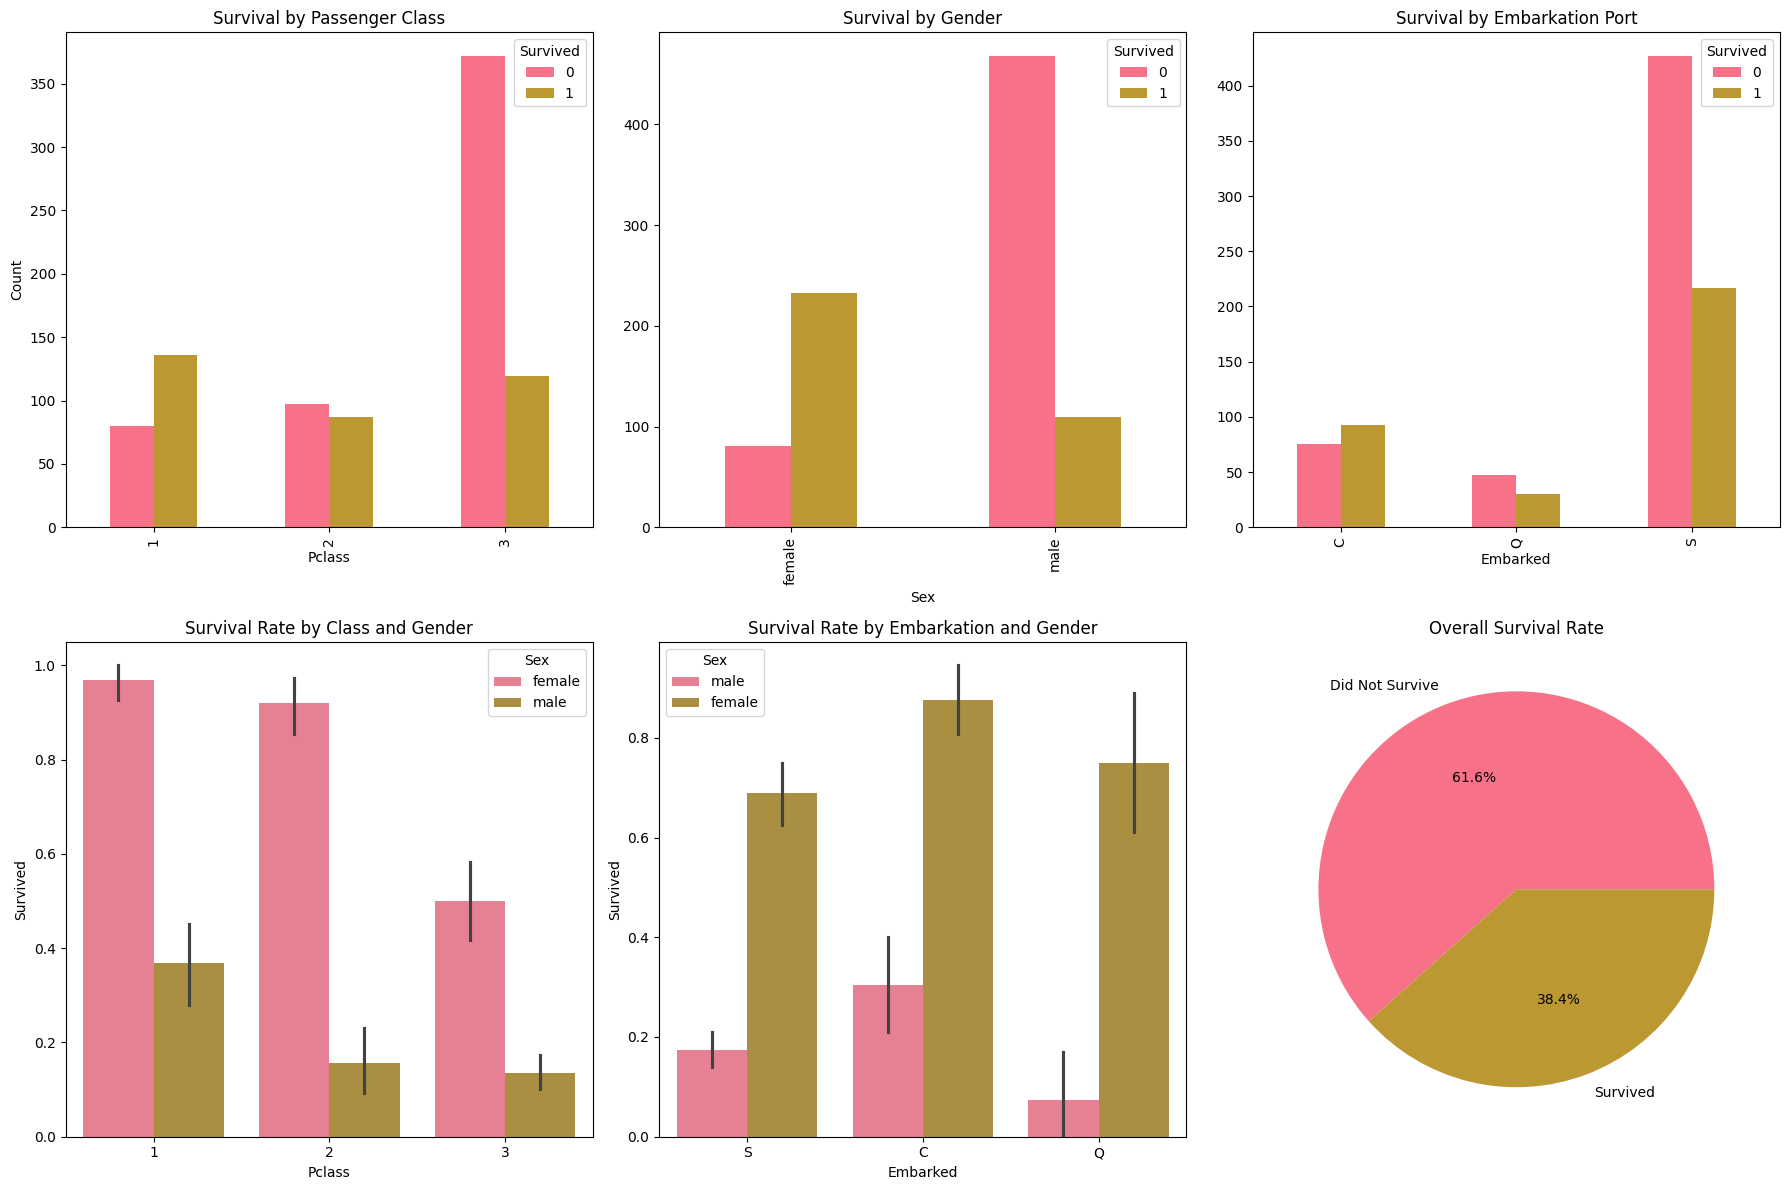

/tmp/ipython-input-3600957506.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Did Not Survive', 'Survived'])
/tmp/ipython-input-3600957506.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Did Not Survive', 'Survived'])


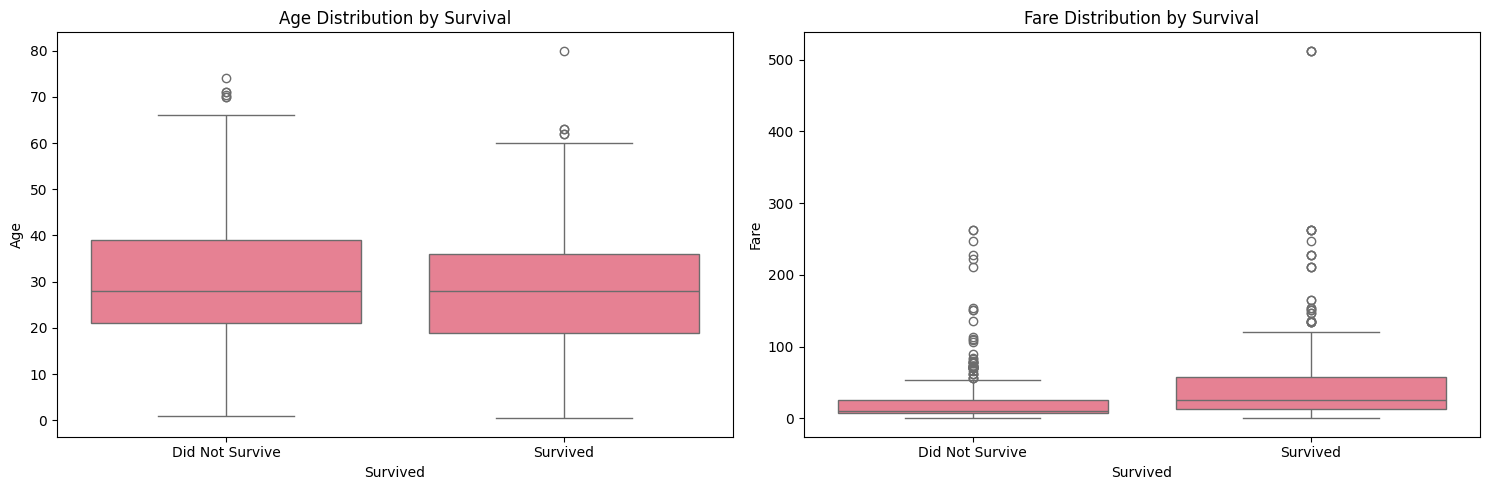

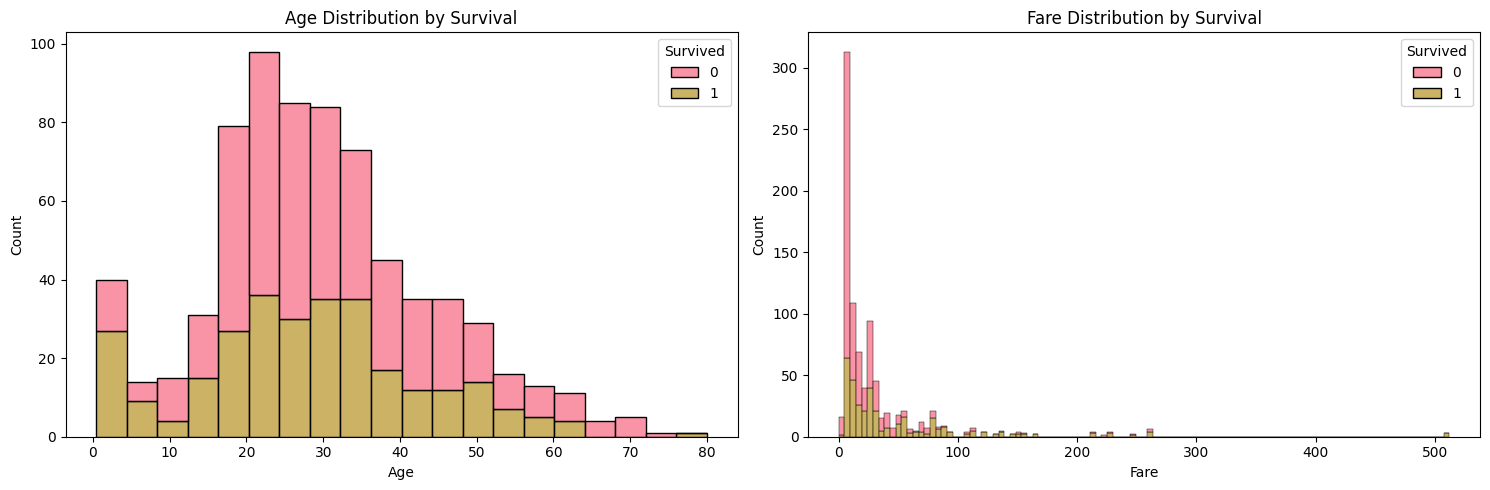

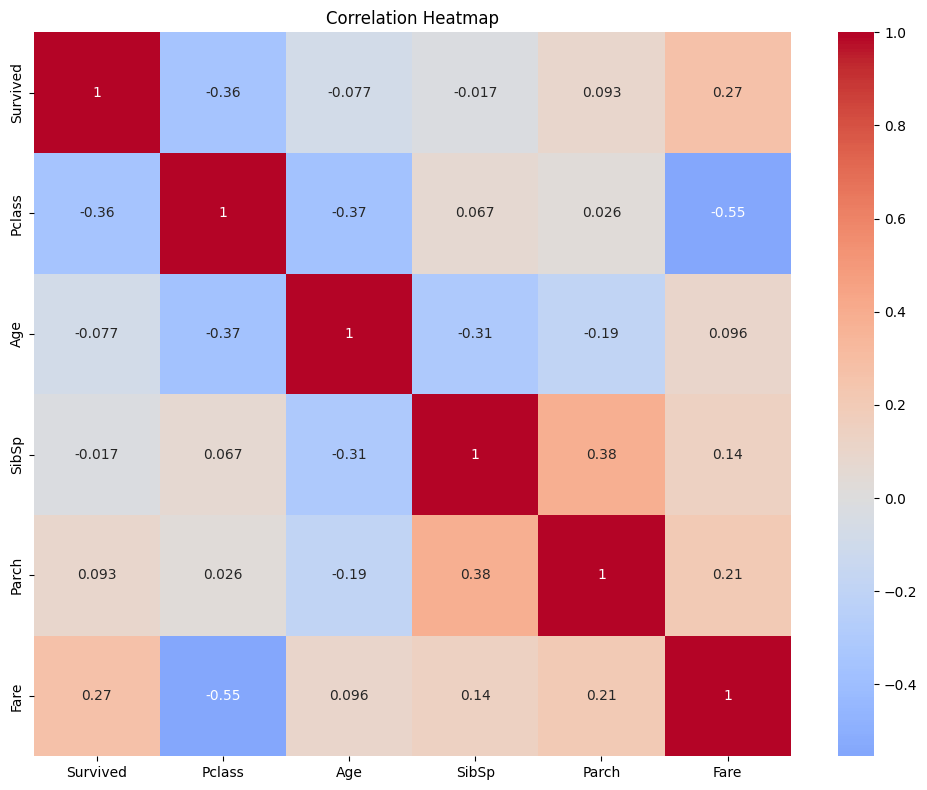


KEY INSIGHTS
Overall survival rate: 38.38%
Survival rate by class:
  Class 1: 62.96%
  Class 2: 47.28%
  Class 3: 24.24%

Survival rate by gender:
  male: 18.89%
  female: 74.20%

Average age: 29.7 years
Average fare: $32.20


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# 1. Survival Analysis Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Survival by Class
survival_by_class = train_df.groupby(['Pclass', 'Survived']).size().unstack()
survival_by_class.plot(kind='bar', ax=axes[0,0], title='Survival by Passenger Class')
axes[0,0].set_ylabel('Count')

# Survival by Gender
survival_by_sex = train_df.groupby(['Sex', 'Survived']).size().unstack()
survival_by_sex.plot(kind='bar', ax=axes[0,1], title='Survival by Gender')

# Survival by Embarkation Port
survival_by_embarked = train_df.groupby(['Embarked', 'Survived']).size().unstack()
survival_by_embarked.plot(kind='bar', ax=axes[0,2], title='Survival by Embarkation Port')

# Survival Rate by Class and Gender
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=train_df, ax=axes[1,0])
axes[1,0].set_title('Survival Rate by Class and Gender')

# Survival Rate by Embarkation and Gender
sns.barplot(x='Embarked', y='Survived', hue='Sex', data=train_df, ax=axes[1,1])
axes[1,1].set_title('Survival Rate by Embarkation and Gender')

# Overall survival pie chart
survival_counts = train_df['Survived'].value_counts()
axes[1,2].pie(survival_counts.values, labels=['Did Not Survive', 'Survived'], autopct='%1.1f%%')
axes[1,2].set_title('Overall Survival Rate')

plt.tight_layout()
plt.show()

# 2. Cleaned-up Boxplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Age distribution by survival
sns.boxplot(x='Survived', y='Age', data=train_df, ax=axes[0])
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xticklabels(['Did Not Survive', 'Survived'])

# Fare distribution by survival
sns.boxplot(x='Survived', y='Fare', data=train_df, ax=axes[1])
axes[1].set_title('Fare Distribution by Survival')
axes[1].set_xticklabels(['Did Not Survive', 'Survived'])

plt.tight_layout()
plt.show()

# 3. Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Age distribution
sns.histplot(data=train_df, x='Age', hue='Survived', multiple='stack', ax=axes[0])
axes[0].set_title('Age Distribution by Survival')

# Fare distribution
sns.histplot(data=train_df, x='Fare', hue='Survived', multiple='stack', ax=axes[1])
axes[1].set_title('Fare Distribution by Survival')

plt.tight_layout()
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(10, 8))
numerical_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
numerical_df = train_df[numerical_cols].dropna()

correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Print key insights
print("\n" + "="*50)
print("KEY INSIGHTS")
print("="*50)

print(f"Overall survival rate: {train_df['Survived'].mean():.2%}")
print(f"Survival rate by class:")
for pclass in sorted(train_df['Pclass'].unique()):
    rate = train_df[train_df['Pclass'] == pclass]['Survived'].mean()
    print(f"  Class {pclass}: {rate:.2%}")

print(f"\nSurvival rate by gender:")
for gender in train_df['Sex'].unique():
    rate = train_df[train_df['Sex'] == gender]['Survived'].mean()
    print(f"  {gender}: {rate:.2%}")

print(f"\nAverage age: {train_df['Age'].mean():.1f} years")
print(f"Average fare: ${train_df['Fare'].mean():.2f}")

In [7]:
train_df_processed = train_df.copy()

In [8]:
# 1. Handling Missing Values

# Impute 'Age' with the median
imputer_age = SimpleImputer(strategy='median')
train_df_processed['Age'] = imputer_age.fit_transform(train_df_processed[['Age']]).ravel()

# Impute 'Embarked' with the mode
imputer_embarked = SimpleImputer(strategy='most_frequent')
train_df_processed['Embarked'] = imputer_embarked.fit_transform(train_df_processed[['Embarked']]).ravel()

# 2. Feature Engineering and Dropping Columns

# Drop 'PassengerId', 'Name', 'Ticket', and 'Cabin'
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
train_df_processed = train_df_processed.drop(columns=columns_to_drop)

# 3. Encoding Categorical Variables

# 'Sex' - Label Encoding
le = LabelEncoder()
train_df_processed['Sex'] = le.fit_transform(train_df_processed['Sex'])

# 'Pclass' and 'Embarked' - One-Hot Encoding
train_df_processed = pd.get_dummies(train_df_processed, columns=['Pclass', 'Embarked'], drop_first=True)


In [9]:
train_df_processed

,Survived,Sex,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Embarked_Q,Embarked_S
0,0,1,22.0,1,0,7.2500,False,True,False,True
1,1,0,38.0,1,0,71.2833,False,False,False,False
2,1,0,26.0,0,0,7.9250,False,True,False,True
3,1,0,35.0,1,0,53.1000,False,False,False,True
4,0,1,35.0,0,0,8.0500,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...
886,0,1,27.0,0,0,13.0000,True,False,False,True
887,1,0,19.0,0,0,30.0000,False,False,False,True
888,0,0,28.0,1,2,23.4500,False,True,False,True
889,1,1,26.0,0,0,30.0000,False,False,False,False


In [10]:
Y = train_df_processed['Survived']
X = train_df_processed[['Age', 'Sex', 'SibSp', 'Parch', 'Fare', 'Pclass_2', 'Pclass_3', 'Embarked_Q', 'Embarked_S']]

In [11]:
indices = np.arange(train_df_processed.shape[0])

In [12]:
rnd = np.random.RandomState(123)
shuffled_indices = rnd.permutation(indices)
shuffled_indices

array([172, 524, 452, 170, 620, 397, 161,  41, 702, 567, 147, 100, 820,
       676, 177, 644, 195, 185, 167, 117, 888, 237, 795, 171, 824, 353,
       521, 307, 646, 560, 642, 670, 722, 509, 145, 731, 699, 406, 345,
       209, 435,  48, 240, 483, 138, 134, 577,  35, 131, 316, 367, 813,
       227,   4, 864, 522, 266, 688, 336, 683, 809, 700, 802, 306, 210,
       616, 463, 723, 270, 303,  52, 482, 740,  54, 408, 313, 860, 491,
       375,  31, 617, 735, 182,  36, 294, 239, 381, 285,  55, 784, 677,
       547, 317, 261, 273, 715, 310, 269, 103, 600, 164, 659, 536, 875,
       196, 671, 810,  57, 614, 327,  78, 690, 318, 769, 162, 236, 694,
       249, 775, 748, 566, 668, 707,   5, 551, 861, 678, 602, 727,  91,
       523,  90,  75, 726, 862, 675, 299, 799, 511, 272, 280, 632, 532,
       831, 448, 200,  13,  74, 821, 641, 599,  59, 816, 764, 151, 531,
        11, 777, 865, 796, 346, 822, 370, 498, 633, 356, 774, 640, 274,
       188, 753, 351, 229, 848, 388, 338, 827, 773, 221, 329, 74

In [13]:
train_df_shuffled = train_df_processed.iloc[shuffled_indices]
train_df_shuffled

,Survived,Sex,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Embarked_Q,Embarked_S
172,1,0,1.0,1,1,11.1333,False,True,False,True
524,0,1,28.0,0,0,7.2292,False,True,False,False
452,0,1,30.0,0,0,27.7500,False,False,False,False
170,0,1,61.0,0,0,33.5000,False,False,False,True
620,0,1,27.0,1,0,14.4542,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
98,1,0,34.0,0,1,23.0000,True,False,False,True
322,1,0,30.0,0,0,12.3500,True,False,True,False
382,0,1,32.0,0,0,7.9250,False,True,False,True
365,0,1,30.0,0,0,7.2500,False,True,False,True


In [14]:
Y_shuffled= train_df_shuffled['Survived'].values.astype(int)

X_shuffled = train_df_shuffled[['Age', 'Sex', 'SibSp', 'Parch', 'Fare', 'Pclass_2', 'Pclass_3', 'Embarked_Q', 'Embarked_S']].values.astype(float)


In [15]:
# Normalize features
X_shuffled = (X_shuffled - X_shuffled.mean(axis=0)) / (X_shuffled.std(axis=0) + 1e-8)


In [16]:
x_train_shuffled, y_train_shuffled = X_shuffled[:712], Y_shuffled[:712]
x_test_shuffled, y_test_shuffled = X_shuffled[712:], Y_shuffled[712:]

In [17]:
import numpy as np

class DecisionStump:
    def __init__(self):
        self.feature_index = None
        self.threshold = None
        self.left_pred = None
        self.right_pred = None

    def fit(self, X, y, sample_weights):
        best_loss = float('inf')
        n_samples, n_features = X.shape

        for feature_index in range(n_features):
            feature_values = X[:, feature_index]
            unique_values = np.unique(feature_values)

            # Try multiple thresholds between unique values for better splits
            if len(unique_values) > 1:
                thresholds = (unique_values[:-1] + unique_values[1:]) / 2
            else:
                thresholds = unique_values

            for threshold in thresholds:
                left_mask = feature_values <= threshold
                right_mask = feature_values > threshold

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                # Use weighted averages instead of just sign for better predictions
                left_pred = np.average(y[left_mask], weights=sample_weights[left_mask])
                right_pred = np.average(y[right_mask], weights=sample_weights[right_mask])

                # Use weighted MSE loss instead of classification error
                loss_left = np.sum(sample_weights[left_mask] * (y[left_mask] - left_pred) ** 2)
                loss_right = np.sum(sample_weights[right_mask] * (y[right_mask] - right_pred) ** 2)
                current_loss = loss_left + loss_right

                if current_loss < best_loss:
                    best_loss = current_loss
                    self.feature_index = feature_index
                    self.threshold = threshold
                    self.left_pred = left_pred
                    self.right_pred = right_pred

    def predict(self, X):
        feature_values = X[:, self.feature_index]
        left_mask = feature_values <= self.threshold
        right_mask = feature_values > self.threshold

        y_pred = np.zeros(X.shape[0])
        y_pred[left_mask] = self.left_pred
        y_pred[right_mask] = self.right_pred

        return y_pred

class Custom_lgbmclassifier:
    def __init__(self, n_estimators=100, learning_rate=0.1, subsample=0.8, colsample=0.8, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.subsample = subsample  # Fraction of samples to use for each tree
        self.colsample = colsample  # Fraction of features to use for each tree
        self.random_state = random_state
        self.models = []
        self.model_weights = []
        self.initial_pred = None

    def _compute_gradient(self, y, predictions):
        """Compute negative gradient for binary classification"""
        # For binary classification with log loss, gradient = y - sigmoid(predictions)
        # But since we're using regression trees, we use y - predictions directly
        return y - predictions

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape

        # Convert binary labels from {0,1} to {-1,1} for better gradient boosting
        y_transformed = np.where(y == 0, -1, 1)

        # Initialize with mean prediction
        self.initial_pred = np.mean(y_transformed)
        predictions = np.full(n_samples, self.initial_pred)

        for i in range(self.n_estimators):
            # Compute negative gradient (pseudo-residuals)
            residuals = self._compute_gradient(y_transformed, predictions)

            # Subsample data (stochastic gradient boosting)
            if self.subsample < 1.0:
                subsample_size = int(self.subsample * n_samples)
                sample_indices = np.random.choice(n_samples, subsample_size, replace=False)
                X_sub = X[sample_indices]
                residuals_sub = residuals[sample_indices]
                sample_weights = np.ones(subsample_size)
            else:
                X_sub = X
                residuals_sub = residuals
                sample_weights = np.ones(n_samples)

            # Subsample features (like Random Forest)
            if self.colsample < 1.0:
                n_cols = int(self.colsample * n_features)
                feature_indices = np.random.choice(n_features, n_cols, replace=False)
                X_sub_cols = X_sub[:, feature_indices]
            else:
                feature_indices = np.arange(n_features)
                X_sub_cols = X_sub

            # Fit decision stump on subsampled data
            stump = DecisionStump()
            stump.fit(X_sub_cols, residuals_sub, sample_weights)

            # Make predictions (handle feature subsampling)
            if self.colsample < 1.0:
                # Use only the selected features for prediction
                X_pred_cols = X[:, feature_indices]
                stump_pred = stump.predict(X_pred_cols)
            else:
                stump_pred = stump.predict(X)

            # Update predictions with learning rate
            predictions += self.learning_rate * stump_pred

            # Store the model and remember which features were used
            self.models.append((stump, feature_indices))
            self.model_weights.append(self.learning_rate)

    def predict(self, X):
        # Start with initial prediction
        final_predictions = np.full(X.shape[0], self.initial_pred)

        # Add contributions from all stumps
        for (stump, feature_indices), weight in zip(self.models, self.model_weights):
            if len(feature_indices) < X.shape[1]:
                # Use only the features that were used during training
                X_sub = X[:, feature_indices]
                stump_pred = stump.predict(X_sub)
            else:
                stump_pred = stump.predict(X)

            final_predictions += weight * stump_pred

        # Convert back to binary predictions
        # Since we transformed y to {-1,1}, positive values indicate class 1
        return (final_predictions > 0).astype(int)

    def predict_proba(self, X):
        """Predict class probabilities"""
        final_predictions = np.full(X.shape[0], self.initial_pred)

        for (stump, feature_indices), weight in zip(self.models, self.model_weights):
            if len(feature_indices) < X.shape[1]:
                X_sub = X[:, feature_indices]
                stump_pred = stump.predict(X_sub)
            else:
                stump_pred = stump.predict(X)

            final_predictions += weight * stump_pred

        # Apply sigmoid to get probabilities for class 1
        probabilities = 1 / (1 + np.exp(-final_predictions))
        return np.column_stack([1 - probabilities, probabilities])

    def calculate_metrics_manual(y_true, y_pred):
      """Calculate metrics manually without scikit-learn"""
      tp = np.sum((y_true == 1) & (y_pred == 1))
      tn = np.sum((y_true == 0) & (y_pred == 0))
      fp = np.sum((y_true == 0) & (y_pred == 1))
      fn = np.sum((y_true == 1) & (y_pred == 0))

      accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
      precision = tp / (tp + fp) if (tp + fp) > 0 else 0
      recall = tp / (tp + fn) if (tp + fn) > 0 else 0
      f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

      return accuracy, precision, recall, f1

In [18]:
x_train_shuffled

array([[-2.17958317, -1.35557351,  0.43279336, ...,  0.90258735,
        -0.30756233,  0.61583841],
       [-0.1046374 ,  0.73769512, -0.47454519, ...,  0.90258735,
        -0.30756233, -1.62380251],
       [ 0.04906229,  0.73769512, -0.47454519, ..., -1.10792597,
        -0.30756233, -1.62380251],
       ...,
       [-0.1046374 ,  0.73769512, -0.47454519, ..., -1.10792597,
        -0.30756233,  0.61583841],
       [ 0.81756072, -1.35557351, -0.47454519, ..., -1.10792597,
        -0.30756233,  0.61583841],
       [ 0.9712604 ,  0.73769512, -0.47454519, ...,  0.90258735,
        -0.30756233,  0.61583841]])

In [19]:
custom_lgbm = Custom_lgbmclassifier()
custom_lgbm.fit(x_train_shuffled, y_train_shuffled)
y_custom_pred = custom_lgbm.predict(x_test_shuffled)
print(f"Prediction: {y_custom_pred}")
print(f"True Labels: {y_test_shuffled}")

Prediction: [1 0 0 1 0 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 1 1 1 0 0 0 1 0 0 1
 0 1 1 1 0 1 0 0 1 0 1 0 0 0 0 1 1 0 0 1 0 0 0 0 1 1 0 0 1 0 1 1 0 1 0 0 0
 0 1 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 1 1 1 0 1 0 1 1 0 0 1 0 1 0 0 1 0 0
 0 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 0 1 0 1 0 0 0 1 1 1 1 1 1 1 0
 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 1 0 1 0 0 1 1 0 0 1 1 1 0 0 0]
True Labels: [1 0 0 1 0 0 0 1 0 1 1 0 0 0 1 0 0 1 0 0 0 1 1 0 0 1 0 0 1 1 0 0 0 1 0 1 1
 0 1 1 1 1 1 0 0 1 0 0 0 1 1 0 1 1 0 0 1 0 1 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0
 0 1 1 1 0 1 1 1 0 0 0 0 0 1 0 0 0 1 0 1 1 1 0 1 0 0 1 0 0 1 0 1 0 1 1 0 0
 1 0 0 0 1 0 1 1 1 1 0 1 0 0 1 0 0 0 0 1 0 1 0 1 0 1 0 0 0 1 1 1 1 1 1 1 0
 1 0 1 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 1 1 1 0 1 1 1 1 0 0 1]


In [20]:
custom_accuracy , custom_precision , custom_recall, custom_f1_score = Custom_lgbmclassifier.calculate_metrics_manual(y_test_shuffled,y_custom_pred)
print(f"Custom Accuracy: {custom_accuracy}")
print(f"Custom Precision: {custom_precision}")
print(f"Custom Recall: {custom_recall}")
print(f"Custom F1-Score: {custom_f1_score}")

Custom Accuracy: 0.8324022346368715
Custom Precision: 0.8611111111111112
Custom Recall: 0.7560975609756098
Custom F1-Score: 0.8051948051948052


# Using Inbuilt Library

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()

In [24]:
X_scaled= scaler.fit_transform(X)

In [25]:
X_scaled

array([[-0.56573646,  0.73769513,  0.43279337, ...,  0.90258736,
        -0.30756234,  0.61583843],
       [ 0.66386103, -1.35557354,  0.43279337, ..., -1.10792599,
        -0.30756234, -1.62380254],
       [-0.25833709, -1.35557354, -0.4745452 , ...,  0.90258736,
        -0.30756234,  0.61583843],
       ...,
       [-0.1046374 , -1.35557354,  0.43279337, ...,  0.90258736,
        -0.30756234,  0.61583843],
       [-0.25833709,  0.73769513, -0.4745452 , ..., -1.10792599,
        -0.30756234, -1.62380254],
       [ 0.20276197,  0.73769513, -0.4745452 , ...,  0.90258736,
         3.25137334, -1.62380254]])

In [26]:
x_train, x_test, y_train, y_test = train_test_split(X_scaled,Y, test_size = 0.2, random_state=42)

In [27]:
x_train

array([[ 1.24023486,  0.73769513, -0.4745452 , ..., -1.10792599,
        -0.30756234,  0.61583843],
       [-0.48888662,  0.73769513, -0.4745452 , ..., -1.10792599,
        -0.30756234,  0.61583843],
       [ 0.20276197,  0.73769513, -0.4745452 , ...,  0.90258736,
        -0.30756234,  0.61583843],
       ...,
       [ 0.89441056,  0.73769513,  1.34013193, ...,  0.90258736,
        -0.30756234,  0.61583843],
       [-1.18053521, -1.35557354,  0.43279337, ..., -1.10792599,
        -0.30756234,  0.61583843],
       [-0.6425863 ,  0.73769513, -0.4745452 , ..., -1.10792599,
        -0.30756234,  0.61583843]])

In [28]:
import lightgbm as lgb

In [29]:
lgbm_clf = lgb.LGBMClassifier(objective='binary',
                             metric='binary_logloss',
                             n_estimators=100,
                             learning_rate=0.05,
                             random_state=42)


In [30]:
lgbm_clf.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000343 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 203
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(learning_rate=0.05, metric='binary_logloss', objective='binary',
               random_state=42)

In [31]:
from sklearn.metrics import accuracy_score,balanced_accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [32]:
# 5. Make predictions on the test set
y_pred = lgbm_clf.predict(x_test)

# 6. Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test,y_pred)
print(f"Accuracy on the test set: {accuracy:.4f}")
print(f"Precision on the test set: {precision:.4f}")
print(f"Recall on the test set: {recall:.4f}")
print(f"F1-Score on the test set: {f1:.4f}")

Accuracy on the test set: 0.8380
Precision on the test set: 0.8358
Recall on the test set: 0.7568
F1-Score on the test set: 0.7943


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


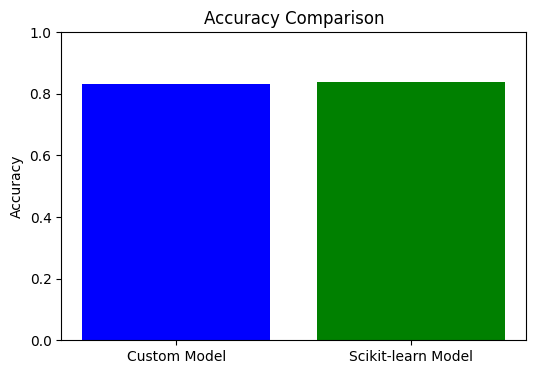

In [33]:
# Assuming 'acc' (custom model training accuracy) and 'accuracy_sklearn_train'
# (scikit-learn model training accuracy) are available from previous steps.

models = ['Custom Model', 'Scikit-learn Model']
accuracies = [custom_accuracy, accuracy]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracies, color=['blue', 'green'])
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.show()

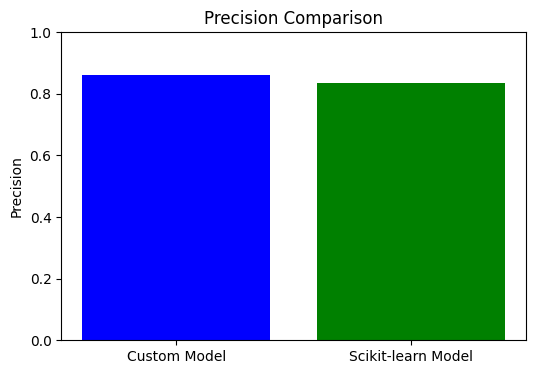

In [34]:
precisions = [custom_precision, precision]

plt.figure(figsize=(6, 4))
plt.bar(models, precisions, color=['blue', 'green'])
plt.ylabel('Precision')
plt.title('Precision Comparison')
plt.ylim(0, 1) # Precision is between 0 and 1
plt.show()

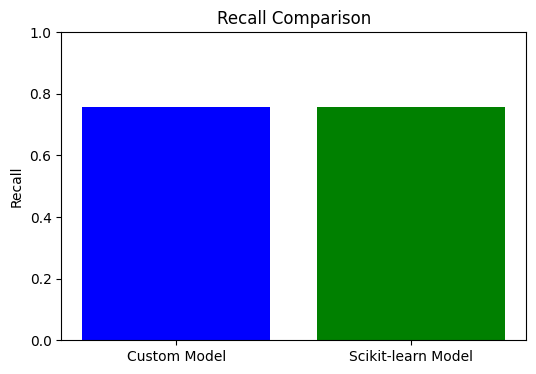

In [35]:
recalls = [custom_recall, recall]

plt.figure(figsize=(6, 4))
plt.bar(models, recalls, color=['blue', 'green'])
plt.ylabel('Recall')
plt.title('Recall Comparison')
plt.ylim(0, 1) # Recall is between 0 and 1
plt.show()

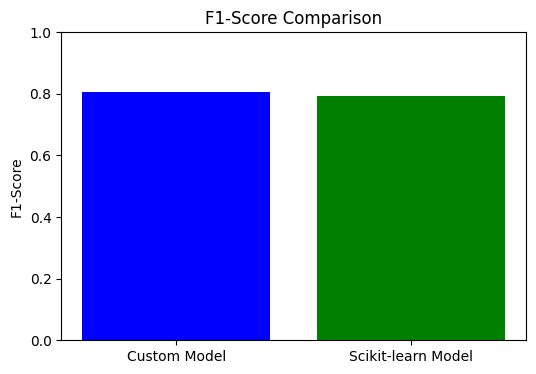

In [36]:
f1_scores = [custom_f1_score, f1]

plt.figure(figsize=(6, 4))
plt.bar(models, f1_scores, color=['blue', 'green'])
plt.ylabel('F1-Score')
plt.title('F1-Score Comparison')
plt.ylim(0, 1) # F1-Score is between 0 and 1
plt.show()

In [38]:
import os
import pickle
import joblib
os.makedirs("models", exist_ok=True)

In [40]:
model_path = "models/inbuilt_LGBM_classifier_model.pkl"
joblib.dump(lgbm_clf, model_path)

print("Model saved to:", model_path)

Model saved to: models/inbuilt_LGBM_classifier_model.pkl


In [41]:
custom_model_path = "models/custom_LGBM_classifier_model.pkl"

with open(custom_model_path, "wb") as f:
    pickle.dump(custom_lgbm, f)

print("Custom model saved at:", custom_model_path)

Custom model saved at: models/custom_LGBM_classifier_model.pkl
